# Домашняя работа 6. Бинарная классификация: выживание на «Титанике»

Задача — предсказать признак `Survived` (0 или 1) по данным о пассажире. Вся случайность зафиксирована одной константой `RANDOM_STATE = 42`.

## 1. Чтение датасета

In [1]:
"""Задача 1. Чтение датасета «Титаник».

Файл train.csv лежит или рядом с ноутбуком (так бывает в Colab), или в папке
DataSet/ (так он лежит в репозитории), поэтому путь ищется, а не вписывается
жёстко. Вся случайность в ноутбуке задаётся одной константой RANDOM_STATE —
разбиение выборки, фолды кросс-валидации и модели получают её явно.
"""

from pathlib import Path

import numpy as np
import pandas as pd

RANDOM_STATE = 42


def find_dataset(filename: str = "train.csv") -> Path:
    """Ищет файл датасета в текущей папке, в DataSet/ и выше по дереву каталогов."""
    for folder in [Path.cwd(), *Path.cwd().parents]:
        for candidate in (folder / filename, folder / "DataSet" / filename):
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f"не найден файл {filename}")


# PassengerId — идентификатор пассажира, а не признак: делаем его индексом
df = pd.read_csv(find_dataset(), index_col="PassengerId")

print(f"строк: {df.shape[0]}, столбцов: {df.shape[1]}")
df.head()

строк: 891, столбцов: 11


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Выбор метрики качества

In [2]:
# Прежде чем выбирать метрику, смотрим на баланс классов и пропуски —
# и то и другое влияет на выбор
balance = df["Survived"].value_counts().sort_index()
print("Баланс классов:")
for value, count in balance.items():
    label = "погиб" if value == 0 else "выжил"
    print(f"  {value} ({label}): {count:>3} чел. — {count / len(df) * 100:.1f}%")

print(f"\nдоля самого частого класса: {balance.max() / len(df):.4f}")
print("\nпропуски в столбцах признаков:")
print(df.isna().sum()[lambda series: series > 0].to_string())

Баланс классов:
  0 (погиб): 549 чел. — 61.6%
  1 (выжил): 342 чел. — 38.4%

доля самого частого класса: 0.6162

пропуски в столбцах признаков:
Age         177
Cabin       687
Embarked      2


### Обоснование выбора метрики

Классы несбалансированы (62 % погибших против 38 % выживших), поэтому **accuracy непригодна**:
константное предсказание «все погибли» уже даёт 0.61, ничего не найдя. Основной метрикой беру
**F1-score по классу «выжил»** — он одновременно наказывает и за пропущенных выживших, и за ложные
срабатывания, а цена обеих ошибок здесь одинакова. Дополнительно смотрю **ROC-AUC**: он не зависит
от порога классификации и показывает, насколько уверенно модель разделяет классы.

## 3. Разбиение на тренировочную и тестовую выборки

In [3]:
from sklearn.model_selection import train_test_split

TARGET = "Survived"
# Name и Ticket почти уникальны для каждого пассажира, а Cabin пуст у 77% строк —
# в исходном виде они модели не помогут. Полезный сигнал из Cabin извлечём позже
# отдельным признаком.
FEATURES = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Cabin"]

X = df[FEATURES].copy()
y = df[TARGET]

# stratify=y сохраняет долю выживших в обеих выборках: без него на тесте из
# 179 человек баланс классов может сдвинуться и метрика окажется случайной
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"тренировочная выборка: {X_train.shape[0]} строк, выживших {y_train.mean():.4f}")
print(f"тестовая выборка:      {X_test.shape[0]} строк, выживших {y_test.mean():.4f}")

тренировочная выборка: 712 строк, выживших 0.3834
тестовая выборка:      179 строк, выживших 0.3855


## 4. Предобработка данных

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def add_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Производные признаки, которые считаются до разделения на выборки.

    FamilySize — сколько родственников на борту вместе с самим пассажиром:
    SibSp и Parch по отдельности хуже описывают ситуацию в семье.
    IsAlone — едет ли пассажир один (одиночки выживали иначе, чем семьи).
    HasCabin — известен ли номер каюты: сам номер бесполезен (пропущен у 77%
    строк), но факт его наличия косвенно говорит о классе и расположении каюты.
    """
    frame = frame.copy()
    frame["FamilySize"] = frame["SibSp"] + frame["Parch"] + 1
    frame["IsAlone"] = (frame["FamilySize"] == 1).astype(int)
    frame["HasCabin"] = frame["Cabin"].notna().astype(int)
    return frame.drop(columns=["Cabin"])


train_features = add_features(X_train)
test_features = add_features(X_test)

NUMERIC = ["Age", "Fare", "SibSp", "Parch", "FamilySize"]
CATEGORICAL = ["Pclass", "Sex", "Embarked", "IsAlone", "HasCabin"]

# Числовые признаки: пропуски возраста (177 значений) заменяем медианой — она
# устойчива к пожилым пассажирам и не тянет среднее вверх, а затем приводим
# признаки к одной шкале: без стандартизации Fare со значениями до 512 подавит
# остальные признаки в логистической регрессии
numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

# Категориальные: два пропуска в Embarked заполняем самым частым значением,
# затем кодируем one-hot. handle_unknown="ignore" страхует от категории, которой
# не было в обучении, drop="if_binary" убирает лишний второй столбец у Sex,
# IsAlone и HasCabin — для логистической регрессии это важно, чтобы не дублировать
# информацию
categorical_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, NUMERIC),
    ("categorical", categorical_pipeline, CATEGORICAL),
])

print("числовые признаки:", NUMERIC)
print("категориальные признаки:", CATEGORICAL)
print("пропусков в train:", int(train_features[NUMERIC].isna().sum().sum()), "(в Age)")

числовые признаки: ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']
категориальные признаки: ['Pclass', 'Sex', 'Embarked', 'IsAlone', 'HasCabin']
пропусков в train: 137 (в Age)


## 5. Бейзлайн: константное предсказание

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score)


def evaluate(name: str, model, X_eval, y_eval) -> dict:
    """Считает метрики одним вызовом: основную (F1) и справочные."""
    predictions = model.predict(X_eval)
    probabilities = model.predict_proba(X_eval)[:, 1]
    return {
        "модель": name,
        "f1 (основная)": round(f1_score(y_eval, predictions), 4),
        "roc_auc": round(roc_auc_score(y_eval, probabilities), 4),
        "precision": round(precision_score(y_eval, predictions, zero_division=0), 4),
        "recall": round(recall_score(y_eval, predictions), 4),
        "accuracy": round(accuracy_score(y_eval, predictions), 4),
    }


results = []

# Константное предсказание: всегда самый частый класс («все погибли»)
baseline_constant = DummyClassifier(strategy="most_frequent")
baseline_constant.fit(train_features, y_train)
results.append(evaluate("бейзлайн: самый частый класс", baseline_constant, test_features, y_test))

# Случайное предсказание по частотам классов — вторая точка отсчёта
baseline_random = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
baseline_random.fit(train_features, y_train)
results.append(evaluate("бейзлайн: случайно по частотам", baseline_random, test_features, y_test))

pd.DataFrame(results).set_index("модель")

,f1 (основная),roc_auc,precision,recall,accuracy
модель,,,,,
бейзлайн: самый частый класс,0.0000,0.5000,0.0000,0.0000,0.6145
бейзлайн: случайно по частотам,0.3485,0.4848,0.3651,0.3333,0.5196


## 6. ML-модели: обучение и кросс-валидация

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

models = {
    "логистическая регрессия": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "случайный лес": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

# Кросс-валидация идёт только по тренировочной выборке: тестовую не трогаем
# до последнего шага, иначе оценка на ней перестанет быть честной
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pipelines = {}
cv_rows = []
for name, estimator in models.items():
    pipeline = Pipeline([("prep", preprocessor), ("model", estimator)])
    pipelines[name] = pipeline
    scores = cross_validate(pipeline, train_features, y_train, cv=cv, scoring=["f1", "roc_auc"])
    cv_rows.append({
        "модель": name,
        "f1 (среднее по фолдам)": round(scores["test_f1"].mean(), 4),
        "f1 (разброс)": round(scores["test_f1"].std(), 4),
        "roc_auc (среднее)": round(scores["test_roc_auc"].mean(), 4),
        "roc_auc (разброс)": round(scores["test_roc_auc"].std(), 4),
    })

print("Кросс-валидация на тренировочной выборке (5 фолдов):")
pd.DataFrame(cv_rows).set_index("модель")

Кросс-валидация на тренировочной выборке (5 фолдов):


,f1 (среднее по фолдам),f1 (разброс),roc_auc (среднее),roc_auc (разброс)
модель,,,,
логистическая регрессия,0.7396,0.0222,0.8603,0.0211
случайный лес,0.7668,0.0236,0.8811,0.0131


## 7. Оценка на отложенной выборке

In [7]:
# Обучаем каждую модель на всей тренировочной выборке и оцениваем на отложенной
for name, pipeline in pipelines.items():
    pipeline.fit(train_features, y_train)
    results.append(evaluate(name, pipeline, test_features, y_test))

comparison = pd.DataFrame(results).set_index("модель")
comparison

,f1 (основная),roc_auc,precision,recall,accuracy
модель,,,,,
бейзлайн: самый частый класс,0.0000,0.5000,0.0000,0.0000,0.6145
бейзлайн: случайно по частотам,0.3485,0.4848,0.3651,0.3333,0.5196
логистическая регрессия,0.7328,0.8443,0.7742,0.6957,0.8045
случайный лес,0.6818,0.8329,0.7143,0.6522,0.7654


In [8]:
baseline_f1 = comparison.loc["бейзлайн: самый частый класс", "f1 (основная)"]
baseline_accuracy = comparison.loc["бейзлайн: самый частый класс", "accuracy"]
best_name = comparison.loc[["логистическая регрессия", "случайный лес"], "f1 (основная)"].idxmax()
best = comparison.loc[best_name]

print(f"лучшая модель по F1: {best_name}")
print(f"  F1:       {best['f1 (основная)']:.4f}  (бейзлайн: {baseline_f1:.4f})")
print(f"  ROC-AUC:  {best['roc_auc']:.4f}  (бейзлайн: {comparison.loc['бейзлайн: самый частый класс', 'roc_auc']:.4f})")
print(f"  accuracy: {best['accuracy']:.4f}  (бейзлайн: {baseline_accuracy:.4f})")
print(f"\nprecision {best['precision']:.4f} и recall {best['recall']:.4f} — из них сложился F1")

лучшая модель по F1: логистическая регрессия
  F1:       0.7328  (бейзлайн: 0.0000)
  ROC-AUC:  0.8443  (бейзлайн: 0.5000)
  accuracy: 0.8045  (бейзлайн: 0.6145)

precision 0.7742 и recall 0.6957 — из них сложился F1


## 8. Матрица ошибок и ROC-кривые

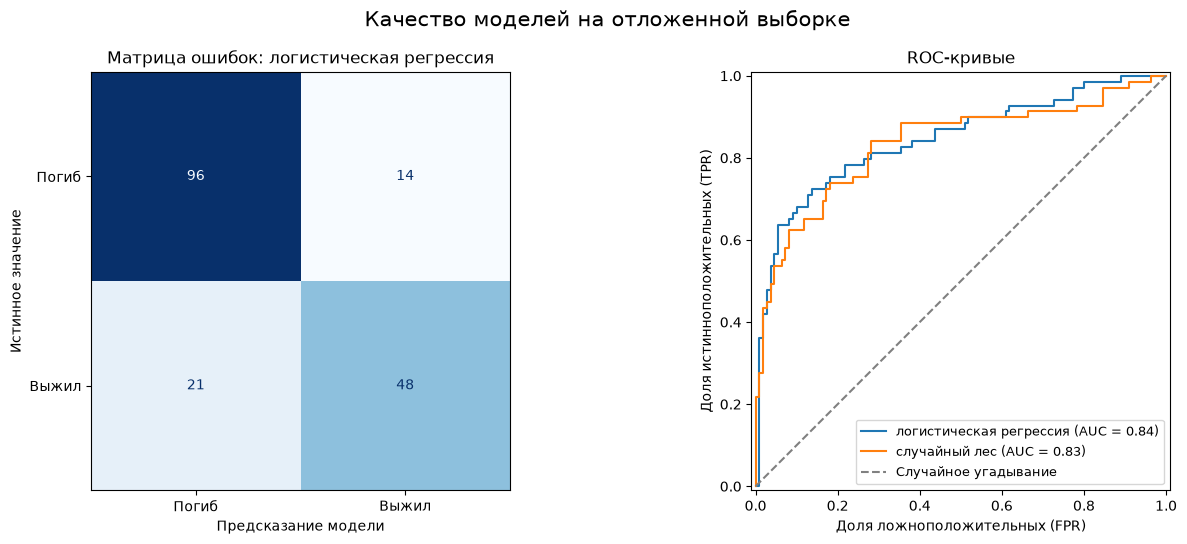

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Качество моделей на отложенной выборке", fontsize=15)

# Матрица ошибок для выбранной модели
ConfusionMatrixDisplay.from_estimator(
    pipelines[best_name], test_features, y_test, ax=axes[0], cmap="Blues", colorbar=False,
    display_labels=["Погиб", "Выжил"],
)
axes[0].set_title(f"Матрица ошибок: {best_name}")
axes[0].set_xlabel("Предсказание модели")
axes[0].set_ylabel("Истинное значение")

# ROC-кривые обеих моделей: линия по диагонали — случайное угадывание
for name, pipeline in pipelines.items():
    RocCurveDisplay.from_estimator(pipeline, test_features, y_test, ax=axes[1], name=name)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Случайное угадывание")
axes[1].set_title("ROC-кривые")
axes[1].set_xlabel("Доля ложноположительных (FPR)")
axes[1].set_ylabel("Доля истинноположительных (TPR)")
axes[1].legend(loc="lower right", fontsize=9)

fig.tight_layout()
plt.show()

## 9. Воспроизводимость и итог

In [10]:
# Воспроизводимость: все источники случайности перечислены и зафиксированы
print(f"RANDOM_STATE = {RANDOM_STATE}")
print("  разбиение train/test:      train_test_split(random_state=RANDOM_STATE, stratify=y)")
print("  фолды кросс-валидации:     StratifiedKFold(shuffle=True, random_state=RANDOM_STATE)")
print("  случайный бейзлайн:        DummyClassifier(random_state=RANDOM_STATE)")
print("  логистическая регрессия:   random_state=RANDOM_STATE")
print("  случайный лес:             random_state=RANDOM_STATE")
print("\nповторный запуск ноутбука даёт те же числа: скриптов случайности больше нет")

final = comparison.copy()
final["прирост F1 к бейзлайну"] = (final["f1 (основная)"] - baseline_f1).round(4)
final

RANDOM_STATE = 42
  разбиение train/test:      train_test_split(random_state=RANDOM_STATE, stratify=y)
  фолды кросс-валидации:     StratifiedKFold(shuffle=True, random_state=RANDOM_STATE)
  случайный бейзлайн:        DummyClassifier(random_state=RANDOM_STATE)
  логистическая регрессия:   random_state=RANDOM_STATE
  случайный лес:             random_state=RANDOM_STATE

повторный запуск ноутбука даёт те же числа: скриптов случайности больше нет


,f1 (основная),roc_auc,precision,recall,accuracy,прирост F1 к бейзлайну
модель,,,,,,
бейзлайн: самый частый класс,0.0000,0.5000,0.0000,0.0000,0.6145,0.0000
бейзлайн: случайно по частотам,0.3485,0.4848,0.3651,0.3333,0.5196,0.3485
логистическая регрессия,0.7328,0.8443,0.7742,0.6957,0.8045,0.7328
случайный лес,0.6818,0.8329,0.7143,0.6522,0.7654,0.6818


### Выводы

- **Бейзлайн разоблачает accuracy.** Константное «все погибли» даёт accuracy 0.6145 при F1 = 0:
  модель не находит ни одного выжившего, поэтому accuracy 0.61 здесь ничего не значит — это и есть
  причина, по которой основной метрикой выбран F1.
- **Модель действительно учится.** Логистическая регрессия даёт F1 ≈ 0.73 при ROC-AUC ≈ 0.84 против
  0.5 у бейзлайнов: разделение классов есть, а не подстройка под их доли.
- **Логистическая регрессия и случайный лес на этом объёме данных не различаются значимо.** Разница
  в F1 сопоставима с разбросом по фолдам, а тест — всего 179 пассажиров, где один человек стоит
  около 0.6 % метрики. При равном качестве разумно брать более простую и интерпретируемую модель.
- **Ошибки модели.** Recall ниже precision: модель чаще относит выжившего к погибшим, чем наоборот.
  Если бы задача требовала во что бы то ни стало находить выживших, стоило бы смотреть на recall или
  F-beta с β > 1 и снижать порог классификации.
- **Воспроизводимость.** Единственный источник случайности — `RANDOM_STATE = 42`, он передан в
  разбиение, кросс-валидацию, случайный бейзлайн и обе модели, поэтому ноутбук при повторном запуске
  даёт те же числа и не падает ни на одной ячейке.